In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = pd.read_excel("Monthly_traffic_data_1992-current.xlsx")

In [ ]:
df = pd.read_excel(
    "Monthly_traffic_data_1992-current.xlsx",
    header=[7, 8]
)

data = df[
    [
        ('Unnamed: 0_level_0', 'Year'),
        ('Unnamed: 1_level_0', 'Month'),
        ('Passengers', 'Total*')
    ]
].copy()

data.columns = ['Year', 'Month', 'Passengers']
data['Year'] = data['Year'].ffill()

months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

data = data[data['Month'].isin(months)].copy()

data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
data = data.dropna(subset=['Year'])
data['Year'] = data['Year'].astype(int)

data['Date'] = pd.to_datetime(
    data['Year'].astype(str) + ' ' + data['Month'],
    format='%Y %B'
)

data.head(15)

,Year,Month,Passengers,Date
0,1992,January,1149822.0,1992-01-01
1,1992,February,1086979.0,1992-02-01
2,1992,March,1276674.0,1992-03-01
3,1992,April,1522522.0,1992-04-01
4,1992,May,1742117.0,1992-05-01
5,1992,June,1737275.0,1992-06-01
6,1992,July,1979900.0,1992-07-01
7,1992,August,2061036.0,1992-08-01
8,1992,September,1867943.0,1992-09-01
9,1992,October,1707752.0,1992-10-01


In [ ]:
event_911 = data[
    (data['Date'] >= '1999-09-01') &
    (data['Date'] <= '2003-09-01')
].copy()

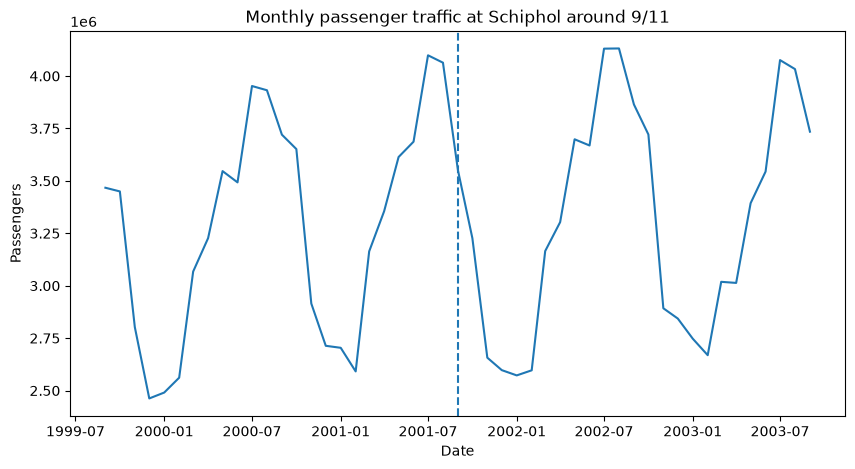

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(event_911['Date'], event_911['Passengers'])

plt.axvline(
    pd.Timestamp('2001-09-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Passengers')
plt.title('Monthly passenger traffic at Schiphol around 9/11')

plt.show()

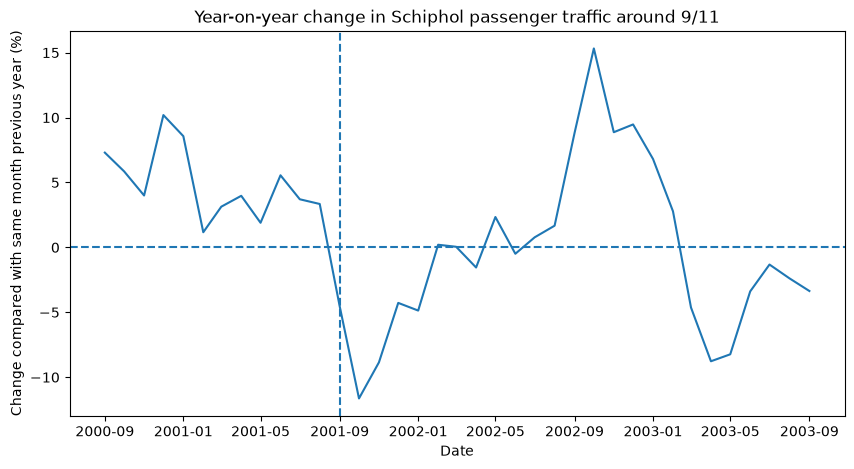

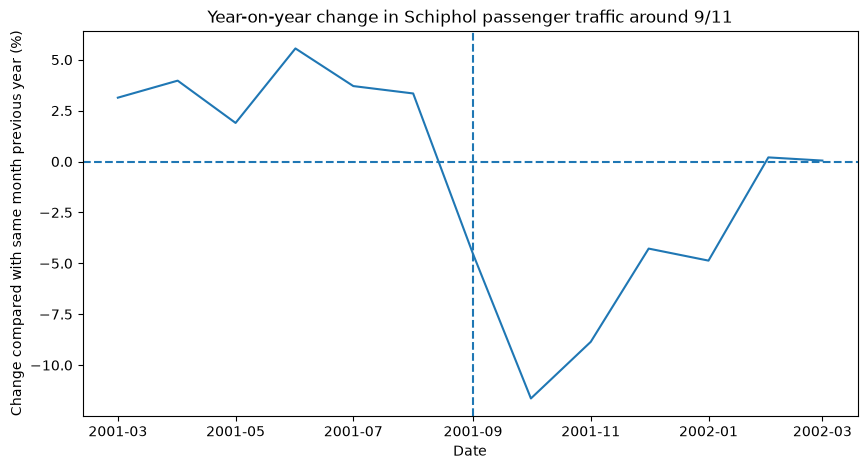

In [ ]:
event_911['Passengers_previous_year'] = event_911['Passengers'].shift(12)

event_911['Year_on_year_change'] = (
    (event_911['Passengers'] - event_911['Passengers_previous_year'])
    / event_911['Passengers_previous_year']
) * 100

plt.figure(figsize=(10, 5))

plt.plot(event_911['Date'], event_911['Year_on_year_change'])

plt.axhline(0, linestyle='--')
plt.axvline(pd.Timestamp('2001-09-01'), linestyle='--')

plt.xlabel('Date')
plt.ylabel('Change compared with same month previous year (%)')
plt.title('Year-on-year change in Schiphol passenger traffic around 9/11')

plt.show()

post_911 = event_911[
    event_911['Date'] >= '2001-09-01'
]

post_911.loc[
    post_911['Year_on_year_change'].idxmin(),
    ['Date', 'Year_on_year_change']
]

zoom_911_6mo = event_911[
    (event_911['Date'] >= '2001-03-01') &
    (event_911['Date'] <= '2002-03-01')
]

plt.figure(figsize=(10, 5))

plt.plot(zoom_911_6mo['Date'], zoom_911_6mo['Year_on_year_change'])

plt.axhline(0, linestyle='--')
plt.axvline(pd.Timestamp('2001-09-01'), linestyle='--')

plt.xlabel('Date')
plt.ylabel('Change compared with same month previous year (%)')
plt.title('Year-on-year change in Schiphol passenger traffic around 9/11')

plt.show()